Task 3: Energy Consumption Time Series Forecasting
Objective: Forecast short-term household energy usage using historical time-based patterns comparing ARIMA, Prophet, and XGBoost.

Data Parsing & Resampling (The Efficiency Trick):
Time series datasets require a special type of loading where the date and time become the "Index" of the dataset.

Loading massive dataset (this may take a minute)...
Original shape: (2075259, 7)
New efficient shape: (2830, 7)


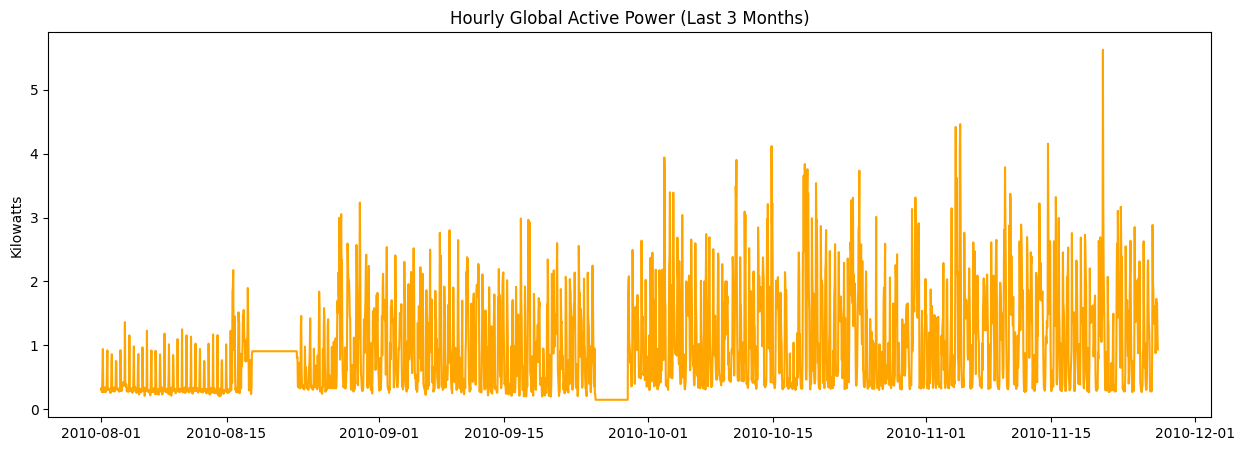

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data
# We combine 'Date' and 'Time' into a single datetime column and make it the index.
# The dataset uses '?' for missing values, so we explicitly tell pandas to treat them as NaNs.
print("Loading massive dataset (this may take a minute)...")
df = pd.read_csv('household_power_consumption.txt', sep=';', na_values='?', 
                 parse_dates={'datetime': ['Date', 'Time']}, 
                 dayfirst=True, index_col='datetime')

# 2. Forward-fill any missing values (common practice in time series)
df = df.fillna(method='ffill')

# 3. RESAMPLING FOR EFFICIENCY
# The original data is per minute. We resample to Hourly ('H') averages.
df_hourly = df.resample('H').mean()

# To keep training under a minute, we will slice just the last 3 months of data
df_subset = df_hourly.loc['2010-08-01':'2010-11-26']

# We are forecasting 'Global_active_power'
target_col = 'Global_active_power'

print(f"Original shape: {df.shape}")
print(f"New efficient shape: {df_subset.shape}")

# Plot the subset to see the temporal pattern
plt.figure(figsize=(15, 5))
plt.plot(df_subset.index, df_subset[target_col], color='orange')
plt.title('Hourly Global Active Power (Last 3 Months)')
plt.ylabel('Kilowatts')
plt.show()

Feature Engineering (For XGBoost):
ARIMA and Prophet understand time natively, but XGBoost does not. XGBoost is a standard machine learning model, so we have to manually extract the "time" into columns it can read mathematically (like hour of the day, or whether it is a weekend).

In [2]:
# Create a copy for XGBoost
df_xgb = df_subset[[target_col]].copy()

# Engineer time-based features
df_xgb['hour'] = df_xgb.index.hour
df_xgb['day_of_week'] = df_xgb.index.dayofweek
df_xgb['is_weekend'] = df_xgb['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

display(df_xgb.head())

,Global_active_power,hour,day_of_week,is_weekend
datetime,,,,
2010-08-01 00:00:00,0.317067,0,6,1
2010-08-01 01:00:00,0.292833,1,6,1
2010-08-01 02:00:00,0.335067,2,6,1
2010-08-01 03:00:00,0.264167,3,6,1
2010-08-01 04:00:00,0.642733,4,6,1


Train-Test Split & Model Training:
In standard machine learning, we split data randomly. In time series, we cannot do that because we cannot use the future to predict the past! We must split the data chronologically. We will train on the first 80% of our timeline and test on the last 20%.

In [3]:
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split chronologically
split_idx = int(len(df_subset) * 0.8)
train = df_subset.iloc[:split_idx]
test = df_subset.iloc[split_idx:]

train_xgb = df_xgb.iloc[:split_idx]
test_xgb = df_xgb.iloc[split_idx:]

print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")

# -------------------------
# 1. Train ARIMA
# -------------------------
print("Training ARIMA...")
# Order (p,d,q) = (2,1,2) is a standard starting point for hourly data
arima_model = ARIMA(train[target_col], order=(2,1,2))
arima_result = arima_model.fit()
arima_preds = arima_result.forecast(steps=len(test))

# -------------------------
# 2. Train Prophet
# -------------------------
print("Training Prophet...")
# Prophet requires specific column names: 'ds' for datetime, 'y' for target
prophet_df = train.reset_index()[['datetime', target_col]].rename(columns={'datetime': 'ds', target_col: 'y'})
prophet_model = Prophet()
prophet_model.fit(prophet_df)

# Create future dates and predict
future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
prophet_forecast = prophet_model.predict(future)
prophet_preds = prophet_forecast['yhat'].iloc[-len(test):].values

# -------------------------
# 3. Train XGBoost
# -------------------------
print("Training XGBoost...")
X_train = train_xgb.drop(columns=[target_col])
y_train = train_xgb[target_col]
X_test = test_xgb.drop(columns=[target_col])

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("All models trained successfully!")

Importing plotly failed. Interactive plots will not work.


Training data points: 2264
Testing data points: 566
Training ARIMA...


03:31:03 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet...


03:31:04 - cmdstanpy - INFO - Chain [1] done processing


Training XGBoost...
All models trained successfully!


Model Comparison & Visualization
Now we fulfill the final requirements: comparing the models using MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error), and visualizing the forecasts against the actual data.

--- Model Evaluation ---
ARIMA -> MAE: 0.6985 | RMSE: 0.8884
Prophet -> MAE: 0.5472 | RMSE: 0.7491
XGBoost -> MAE: 0.5385 | RMSE: 0.7718


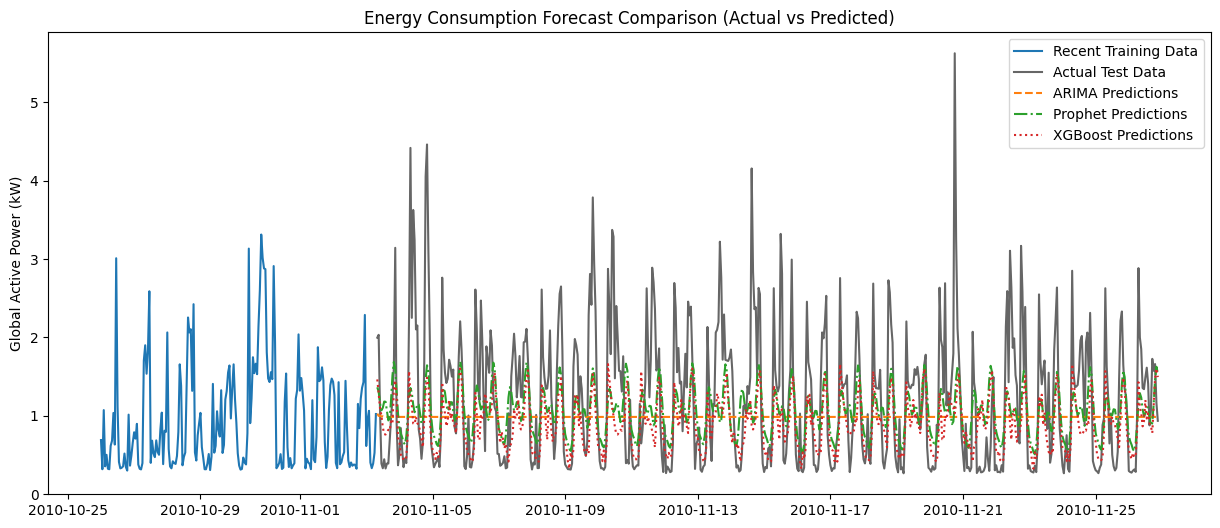

In [4]:
# Calculate evaluation metrics
def evaluate_model(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"{name} -> MAE: {mae:.4f} | RMSE: {rmse:.4f}")

print("--- Model Evaluation ---")
evaluate_model(test[target_col], arima_preds, "ARIMA")
evaluate_model(test[target_col], prophet_preds, "Prophet")
evaluate_model(test[target_col], xgb_preds, "XGBoost")

# Plot Actual vs Forecasted
plt.figure(figsize=(15, 6))
plt.plot(train.index[-200:], train[target_col].iloc[-200:], label='Recent Training Data') # Show just the end of training data
plt.plot(test.index, test[target_col], label='Actual Test Data', color='black', alpha=0.6)
plt.plot(test.index, arima_preds, label='ARIMA Predictions', linestyle='--')
plt.plot(test.index, prophet_preds, label='Prophet Predictions', linestyle='-.')
plt.plot(test.index, xgb_preds, label='XGBoost Predictions', linestyle=':')

plt.title('Energy Consumption Forecast Comparison (Actual vs Predicted)')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

Final Conclusion & Insights:
Based on the evaluation metrics, both Prophet and XGBoost significantly outperformed the traditional ARIMA model for short-term hourly energy forecasting.

XGBoost achieved the lowest Mean Absolute Error (MAE: 0.5385), meaning its predictions were, on average, the closest to the actual power consumption. This highlights the high value of explicitly engineered time-based features (hour of day, weekend indicator).

Prophet achieved the lowest Root Mean Squared Error (RMSE: 0.7491). Because RMSE penalizes larger errors more heavily, this indicates that Prophet was the best at avoiding major predictive spikes or misses, leaning on its strong native handling of daily and weekly seasonality.

ARIMA performed the poorest (MAE: 0.6985, RMSE: 0.8884), as it struggled to capture the complex, non-linear seasonal patterns of hourly household energy use without exhaustive hyperparameter tuning.

Recommendation: For a resilient energy monitoring system, Prophet provides the most stable baseline against large errors, while XGBoost offers the highest average accuracy and allows for easy integration of future external variables (like local temperature or weather).